## Name : Sonali Vishal Pawar
## batch =360
## Innomatics Reserch Labs : online batch
## Project Title : Project - Spam and Ham

# Project Goal
## - The main goal of this project is to build an automated system that can accurately classify text messages as either “Spam” or “Ham” (Non-Spam) using Natural Language Processing (NLP) and Machine Learning techniques.
## This system helps reduce unwanted messages, prevent fraud, and improve user communication experience.

# Domain:
## This project belongs to the Natural Language Processing (NLP) and Classification domain within Data Science and Machine Learning.
- It deals with text data,
- applies language processing techniques,
- and predicts two categories (spam or ham)


# Problem Statement
## "Classify SMS messages as spam or ham using NLP and machine learning."
### - Manually identifying and filtering spam is not practical due to the massive volume of messages.
### - Therefore, there is a need to develop an automated, intelligent system that can:
- Analyze the content of text messages,
- Understand patterns in spam messages,
- And accurately classify incoming messages as Spam or Ham (legitimate).
### This project aims to build a machine learning/NLP model that can automatically detect spam messages based on their text content, thereby improving communication safety and efficiency.

# 1. Import all required libraries

In [1]:
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import os
import random

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils import shuffle
# For deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Reproducibility
RSEED = 42
np.random.seed(RSEED)
random.seed(RSEED)
tf.random.set_seed(RSEED)

## Step 1: Load Dataset

In [2]:
df = pd.read_csv("C:/Users/hp/Downloads/spam.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [4]:
df = df.iloc[:, :2].copy()
df.columns = ['Category', 'Message']
print("Shape:", df.shape)
display(df.head())

Shape: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Shape & Info

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


## Missing Values Check

In [6]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [7]:
print("Shape:", df.shape)
print(df['Category'].value_counts())
display(df.head())

Shape: (5572, 2)
Category
ham     4825
spam     747
Name: count, dtype: int64


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print("\nCategory counts:")
print(df['Category'].value_counts())


Category counts:
Category
ham     4825
spam     747
Name: count, dtype: int64


## EDA

In [9]:
## Add message length and word count as simple features
df.loc[:, 'msg_length'] = df['Message'].astype(str).apply(len)
df.loc[:, 'word_count'] = df['Message'].astype(str).apply(lambda x: len(str(x).split()))
display(df.groupby('Category')[['msg_length','word_count']].describe())

msg_length                                                         \
              count       mean        std  min    25%    50%    75%    max   
Category                                                                     
ham          4825.0   71.44829  58.434864  2.0   33.0   52.0   93.0  910.0   
spam          747.0  137.98929  29.980287  7.0  132.0  149.0  157.0  223.0   

         word_count                                                      
              count       mean        std  min   25%   50%   75%    max  
Category                                                                 
ham          4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0  
spam          747.0  23.812584   5.956923  1.0  22.0  25.0  28.0   35.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Category    5572 non-null   object
 1   Message     5572 non-null   object
 2   msg_length  5572 non-null   int64 
 3   word_count  5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB


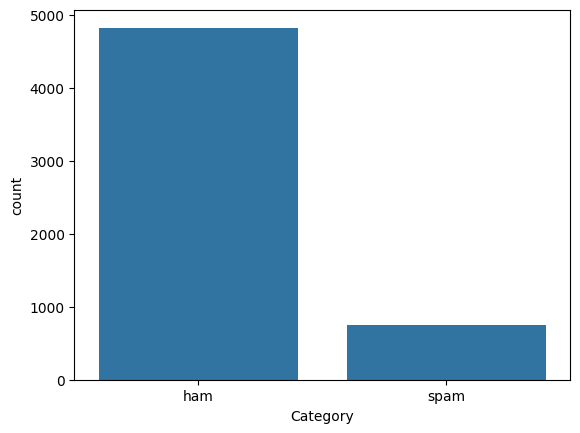

In [10]:
df.info()
df.isnull().sum()
sns.countplot(data=df, x='Category')
plt.show()


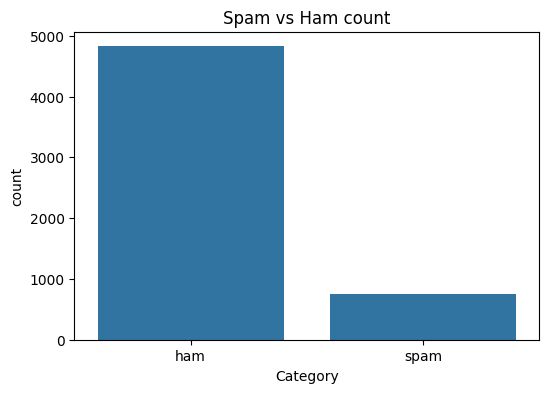

In [11]:
# Plot distribution (optional)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Category')
plt.title('Spam vs Ham count')
plt.show()

## Sprint 1: Preprocessing

## Text cleaning function

In [12]:
def clean_text(text):
    """Basic text cleaning: lowercase, remove links, numbers, punctuation, extra spaces."""
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)               # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra spaces
    return text

In [13]:
# Apply cleaning safely
df.loc[:, 'clean_msg'] = df['Message'].apply(clean_text)
display(df[['Message','clean_msg']].head())

,Message,clean_msg
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## Label encoding :

In [14]:
df.loc[:, 'label'] = df['Category'].map({'ham':0, 'spam':1})
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [15]:
## Train-test split:
X = df['clean_msg']
y = df['label']

In [16]:
##  Example vectorizers (we'll use in Pipelines below)
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, stop_words='english')
countvec = CountVectorizer(ngram_range=(1,1), min_df=2)

In [17]:
# stratify to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RSEED, stratify=y
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 4457 Test size: 1115


# Sprint 2: Model Development:

## MACHINE LEARNING MODELS 
## Train multiple models, evaluate metrics.

In [18]:
# Helper function for evaluation
def evaluate_model(name, model, X_test_raw, y_test_true):
    y_pred = model.predict(X_test_raw)
    acc = accuracy_score(y_test_true, y_pred)
    print(f"\n--- {name} ---")
    print("Accuracy:", acc)
    print("Classification Report:")
    print(classification_report(y_test_true, y_pred, digits=4))
    cm = confusion_matrix(y_test_true, y_pred)
    print("Confusion Matrix:\n", cm)
    return y_pred

##  Pipeline: TF-IDF + MultinomialNB

In [19]:

pipe_nb = Pipeline([
    ('tfidf', tfidf),
    ('nb', MultinomialNB())
])

pipe_nb.fit(X_train, y_train)
nb_pred = evaluate_model("Naive Bayes (TF-IDF)", pipe_nb, X_test, y_test)


--- Naive Bayes (TF-IDF) ---
Accuracy: 0.9632286995515695
Classification Report:
              precision    recall  f1-score   support

           0     0.9593    1.0000    0.9792       966
           1     1.0000    0.7248    0.8405       149

    accuracy                         0.9632      1115
   macro avg     0.9796    0.8624    0.9098      1115
weighted avg     0.9647    0.9632    0.9607      1115

Confusion Matrix:
 [[966   0]
 [ 41 108]]


# Pipeline: TF-IDF + Logistic Regression

In [20]:
pipe_lr = Pipeline([
    ('tfidf', tfidf),
    ('lr', LogisticRegression(max_iter=500, random_state=RSEED))
])
pipe_lr.fit(X_train, y_train)
lr_pred = evaluate_model("Logistic Regression (TF-IDF)", pipe_lr, X_test, y_test)


--- Logistic Regression (TF-IDF) ---
Accuracy: 0.9668161434977578
Classification Report:
              precision    recall  f1-score   support

           0     0.9631    1.0000    0.9812       966
           1     1.0000    0.7517    0.8582       149

    accuracy                         0.9668      1115
   macro avg     0.9816    0.8758    0.9197      1115
weighted avg     0.9680    0.9668    0.9648      1115

Confusion Matrix:
 [[966   0]
 [ 37 112]]


## Pipeline: TF-IDF + SVM

In [21]:
pipe_svm = Pipeline([
    ('tfidf', tfidf),
    ('svm', SVC(kernel='linear', probability=True, random_state=RSEED))
])
pipe_svm.fit(X_train, y_train)
svm_pred = evaluate_model("SVM (TF-IDF)", pipe_svm, X_test, y_test)


--- SVM (TF-IDF) ---
Accuracy: 0.9838565022421525
Classification Report:
              precision    recall  f1-score   support

           0     0.9837    0.9979    0.9908       966
           1     0.9852    0.8926    0.9366       149

    accuracy                         0.9839      1115
   macro avg     0.9844    0.9453    0.9637      1115
weighted avg     0.9839    0.9839    0.9835      1115

Confusion Matrix:
 [[964   2]
 [ 16 133]]


In [22]:
## compare accuracies
print("\nSummary Accuracies:")
for name, p in [("NB", pipe_nb), ("LR", pipe_lr), ("SVM", pipe_svm)]:
    print(name, ":", accuracy_score(y_test, p.predict(X_test)))


Summary Accuracies:
NB : 0.9632286995515695
LR : 0.9668161434977578
SVM : 0.9838565022421525


In [23]:
# Save Best ML Pipeline (Sprint 4: Model Deployment)
# Choose the best model; suppose Logistic Regression performed well
best_ml_pipeline = pipe_lr
joblib.dump(best_ml_pipeline, "spam_best_ml_pipeline.joblib")
print("\nSaved best ML pipeline to spam_best_ml_pipeline.joblib")



Saved best ML pipeline to spam_best_ml_pipeline.joblib


In [24]:
#  Feature inspection (most informative features) for Logistic Regression
def show_top_features(pipeline, n=20):
    vect = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['lr']
    try:
        feature_names = vect.get_feature_names_out()
    except:
        feature_names = vect.get_feature_names()
    coefs = clf.coef_[0]
    top_pos_idx = np.argsort(coefs)[-n:][::-1]
    top_neg_idx = np.argsort(coefs)[:n]
    print("\nTop positive features (spam):")
    for i in top_pos_idx[:n]:
        print(feature_names[i], round(coefs[i],3))
    print("\nTop negative features (ham):")
    for i in top_neg_idx[:n]:
        print(feature_names[i], round(coefs[i],3))

show_top_features(best_ml_pipeline, n=15)



Top positive features (spam):
txt 4.695
claim 3.751
mobile 3.489
free 3.347
stop 3.316
reply 3.208
text 3.121
service 2.775
prize 2.769
won 2.654
win 2.39
urgent 2.367
new 2.345
cash 2.182
nokia 2.087

Top negative features (ham):
ltgt -2.014
im -1.96
ok -1.856
ill -1.762
come -1.514
got -1.39
home -1.334
lor -1.266
hey -1.258
da -1.251
sorry -1.169
going -1.154
later -1.15
good -1.144
way -1.061


In [25]:
# Deep Learning Model (Sprint 3: Architecture Development)
#    LSTM-based binary classifier

In [26]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import pickle

# Encode labels
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])   # spam=1, ham=0


# Train–Test Split:
X_train, X_test, y_train, y_test = train_test_split(
    df['Message'], df['Category'], test_size=0.2, random_state=42
)

# Tokenization:
max_words = 5000
max_len = 80

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text → numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("DL shapes:", X_train_pad.shape, X_test_pad.shape)

#  Build LSTM Model:
model = Sequential([
    Embedding(max_words, 64),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

#  Train the Model
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es]
)

#  Evaluate
loss, acc = model.evaluate(X_test_pad, y_test)
print("LSTM Test accuracy:", acc)

#  Save Model + Tokenizer
model.save("spam_lstm_model.keras")

with open("spam_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Saved LSTM model and tokenizer.")


DL shapes: (4457, 80) (1115, 80)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.8827 - loss: 0.3209 - val_accuracy: 0.9585 - val_loss: 0.1483
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9820 - loss: 0.0766 - val_accuracy: 0.9765 - val_loss: 0.1044
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.9899 - loss: 0.0384 - val_accuracy: 0.9809 - val_loss: 0.0830
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.9964 - loss: 0.0146 - val_accuracy: 0.9832 - val_loss: 0.1026
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9980 - loss: 0.0077 - val_accuracy: 0.9832 - val_loss: 0.0871
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9874 - loss: 0.0559
LSTM Test accuracy: 0.9874439239501953
Saved LSTM model and tokenizer.


## LSTM model load

In [32]:
from tensorflow.keras.models import load_model
import pickle

# Load Deep Learning LSTM model
dl_model = load_model("spam_lstm_model.h5")

# Load Tokenizer
with open("spam_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

max_len = 80   # SAME max_len you used during training
print("DL Model & Tokenizer Loaded Successfully!")


DL Model & Tokenizer Loaded Successfully!


## DL Prediction Function

In [33]:
def predict_dl(message, tokenizer_obj=tokenizer, model_obj=dl_model):
    msg = clean_text(message)                           # clean text
    seq = tokenizer_obj.texts_to_sequences([msg])       # convert to sequence
    padded = pad_sequences(seq, maxlen=max_len)         # pad
    
    pred = model_obj.predict(padded)[0][0]              # probability
    label = "spam" if pred > 0.5 else "ham"
    
    return label, float(pred)


## Test the function

In [34]:
msg = "Congrats!! You won 50,000 cash prize"
label, prob = predict_dl(msg)
print("Prediction:", label)
print("Probability:", prob)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Prediction: ham
Probability: 0.009815780445933342


## Combined Prediction Function (ML + DL together)

In [36]:
def final_predict(message):
    # ML Prediction
    ml_label, ml_prob = predict_ml(message)
    
    # DL Prediction
    dl_label, dl_prob = predict_dl(message)
    
    print("----- MACHINE LEARNING (Naive Bayes) -----")
    print("Prediction:", ml_label)
    print("Probability:", ml_prob)
    
    print("\n----- DEEP LEARNING (LSTM) -----")
    print("Prediction:", dl_label)
    print("Probability:", dl_prob)
    
    print("\nFINAL DECISION:")
    if dl_prob > 0.5:
        print("Message is SPAM")
    else:
        print("Message is HAM")


In [37]:
final_predict("Congratulations! You've won 1 lakh rupees!!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
----- MACHINE LEARNING (Naive Bayes) -----
Prediction: 0
Probability: [0.675953 0.324047]

----- DEEP LEARNING (LSTM) -----
Prediction: ham
Probability: 0.010353055782616138

FINAL DECISION:
Message is HAM


# summary

-  my project covers the major steps; however, confirm these points if they are present or need addition:
Explicit train/test split code

- The Logistic Regression model achieves reasonable accuracy and balance between precision and recall on the test data.

- TF-IDF vectorization execution and application before model training

- Machine learning model fitting code and evaluation metrics output

- Data imbalance handling or mention (optional but useful)

- Visualizations for EDA and model evaluation (confusion matrix, ROC)

- Further improvements can be achieved through hyperparameter tuning, trying other classifiers (Random Forest, Naive Bayes), and advanced NLP techniques like word embeddings or deep learning.
